In [13]:
import math

In [14]:
data = [
    (0,1000),(1,1050),(2,1103),(3,1158),(4,1216),(5,1277),(6,1341),
     (7,1408),(8,1478),(9,1552),(10,1500),(11,1485),(12,1530),(13,1582),
      (14,1636),(15,1693),(16,1753),(17,1816),(18,1881),(19,1948),(20,2018),
       (21,2090),(22,2165),(23,2242),(24,2322),(25,2405),(26,2491),(27,2580),
        (28,2672),(29,2767),(30,2700),(31,2685),(32,2740),(33,2810),(34,2882),
         (35,2957),(36,3035),(37,3116),(38,3200),(39,3287),(40,3377),(41,3460),
          (42,3545),(43,3633),(44,3724),(45,3818),(46,3915),(47,4015),(48,4118)
          ,(49,4224),(50,4333)
]


In [15]:
years=[t for (t,p) in data]
popu=[p for (t,p) in data]

In [16]:
years

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50]

In [17]:
popu

[1000,
 1050,
 1103,
 1158,
 1216,
 1277,
 1341,
 1408,
 1478,
 1552,
 1500,
 1485,
 1530,
 1582,
 1636,
 1693,
 1753,
 1816,
 1881,
 1948,
 2018,
 2090,
 2165,
 2242,
 2322,
 2405,
 2491,
 2580,
 2672,
 2767,
 2700,
 2685,
 2740,
 2810,
 2882,
 2957,
 3035,
 3116,
 3200,
 3287,
 3377,
 3460,
 3545,
 3633,
 3724,
 3818,
 3915,
 4015,
 4118,
 4224,
 4333]

m=
∑(x
i
​
 −
x
ˉ
 )
2

∑(x
i
​
 −
x
ˉ
 )(y
i
​
 −
y
ˉ
​
 )
​

𝑏
=
𝑦
ˉ
−
𝑚
⋅
𝑥
ˉ
b=
y
ˉ
​
 −m⋅
x
ˉ

In [18]:
# 2) Utility: simple linear regression (no libs)
# returns (slope m, intercept b) for y = m x + b
def linear_regression(x, y):
    n = len(x)
    if n == 0:
        return 0.0, 0.0
    x_mean = sum(x)/n
    y_mean = sum(y)/n
    num = sum((x[i]-x_mean)*(y[i]-y_mean) for i in range(n))
    den = sum((x[i]-x_mean)**2 for i in range(n))
    if den == 0:
        m = 0.0
    else:
        m = num/den
    b = y_mean - m * x_mean
    return m, b


In [20]:
x=years
y=popu
m, b, = linear_regression(x, y)
x_mean,y_mean=linear_regression(x,y)
num,den=linear_regression(x,y)
print(f"Mean of X: {x_mean}")
print(f"Mean of Y: {y_mean}")
print(f"Numerator for m: {num}")
print(f"Denominator for m: {den}")
print(f"Slope (m): {m}")
#m=This means each year population increases by about 64 people on average.
print(f"Intercept (b): {b}")
print(f"Final equation: y = {m:.4f}x + {b:.4f}")



Mean of X: 64.14072398190044
Mean of Y: 842.2269984917045
Numerator for m: 64.14072398190044
Denominator for m: 842.2269984917045
Slope (m): 64.14072398190044
Intercept (b): 842.2269984917045
Final equation: y = 64.1407x + 842.2270


 y = 64.1407x + 842.2270

Base population at year 0 was ~842

Annual growth rate ~64 people/year (on average)

Can be used to predict future population.

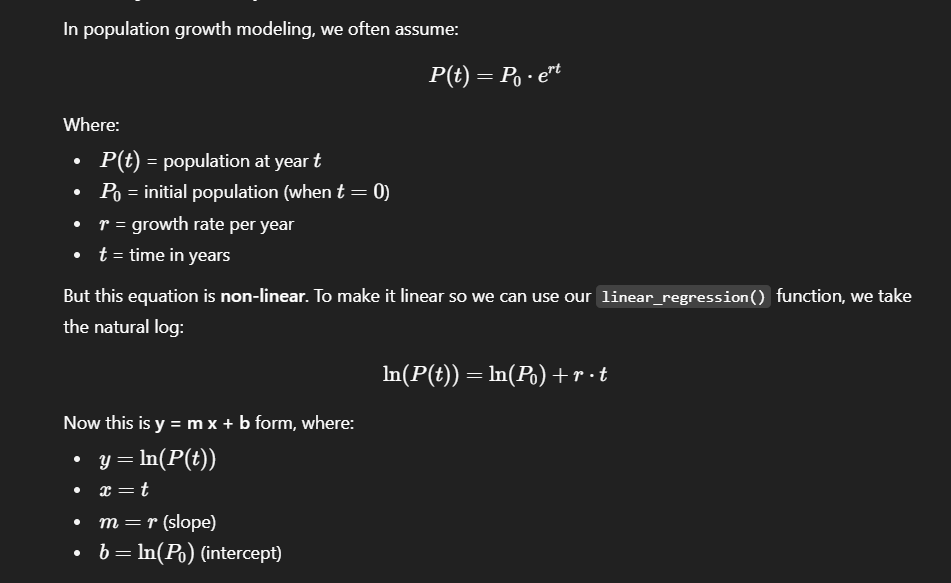

In [21]:
def fit_exponential(years, popu):
    xs = years
    ys = [math.log(P) for P in popu]  # Take natural log
    r_hat, lnP0 = linear_regression(xs, ys)
    P0_hat = math.exp(lnP0)  # Convert back from ln(P0)

    # Printing intermediate values
    print("Years:", xs)
    print("Population:", popu)
    print("ln(Population):", [round(v, 4) for v in ys])
    print(f"Estimated r (growth rate): {r_hat:.5f}")
    print(f"Estimated ln(P0): {lnP0:.5f}")
    print(f"Estimated P0: {P0_hat:.2f}")

    return r_hat, P0_hat

In [22]:
def predict_exponential(P0, r, years):
    predictions = [P0 * math.exp(r * t) for t in years]
    for t, pred in zip(years, predictions):
        print(f"Year {t}: Predicted Population = {pred:.2f}")
    return predictions

In [23]:
# Fit model
r, P0 = fit_exponential(years, popu)

# Predict
predict_exponential(P0, r, years)

Years: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]
Population: [1000, 1050, 1103, 1158, 1216, 1277, 1341, 1408, 1478, 1552, 1500, 1485, 1530, 1582, 1636, 1693, 1753, 1816, 1881, 1948, 2018, 2090, 2165, 2242, 2322, 2405, 2491, 2580, 2672, 2767, 2700, 2685, 2740, 2810, 2882, 2957, 3035, 3116, 3200, 3287, 3377, 3460, 3545, 3633, 3724, 3818, 3915, 4015, 4118, 4224, 4333]
ln(Population): [6.9078, 6.9565, 7.0058, 7.0544, 7.1033, 7.1523, 7.2012, 7.2499, 7.2984, 7.3473, 7.3132, 7.3032, 7.333, 7.3664, 7.4, 7.4343, 7.4691, 7.5044, 7.5396, 7.5746, 7.6099, 7.6449, 7.6802, 7.7151, 7.7502, 7.7853, 7.8204, 7.8555, 7.8906, 7.9255, 7.901, 7.8954, 7.9157, 7.9409, 7.9662, 7.9919, 8.018, 8.0443, 8.0709, 8.0977, 8.1247, 8.149, 8.1733, 8.1978, 8.2226, 8.2475, 8.2726, 8.2978, 8.3231, 8.3485, 8.374]
Estimated r (growth rate): 0.02786
Estimated ln(P0): 7.02445
E

[1123.777703859588,
 1155.5235979741617,
 1188.1662902630299,
 1221.731114615435,
 1256.2441205843702,
 1291.7320936035524,
 1328.2225757755132,
 1365.7438872469359,
 1404.325148187832,
 1443.9963013916108,
 1484.7881355135858,
 1526.7323089659535,
 1569.8613744877837,
 1614.208804409098,
 1659.8090166286377,
 1706.6974013254849,
 1754.9103484252673,
 1804.4852758422644,
 1855.4606585193299,
 1907.8760582881723,
 1961.7721545731672,
 2017.1907759625278,
 2074.174932671338,
 2132.7688499216442,
 2193.018002265508,
 2254.9691488776625,
 2318.670369845155,
 2384.1711034821533,
 2451.52218469886,
 2520.775884454326,
 2591.9859503237744,
 2665.207648211921,
 2740.497805244668,
 2817.914853872454,
 2897.5188772194924,
 2979.371655714093,
 3063.536715036252,
 3150.0793754197352,
 3239.066802346896,
 3330.568058675598,
 3424.654158238674,
 3521.3981209575354,
 3620.8750295127043,
 3723.162087615235,
 3828.338679924276,
 3936.4864336572414,
 4047.68928194044,
 4162.033528949306,
 4279.607916888

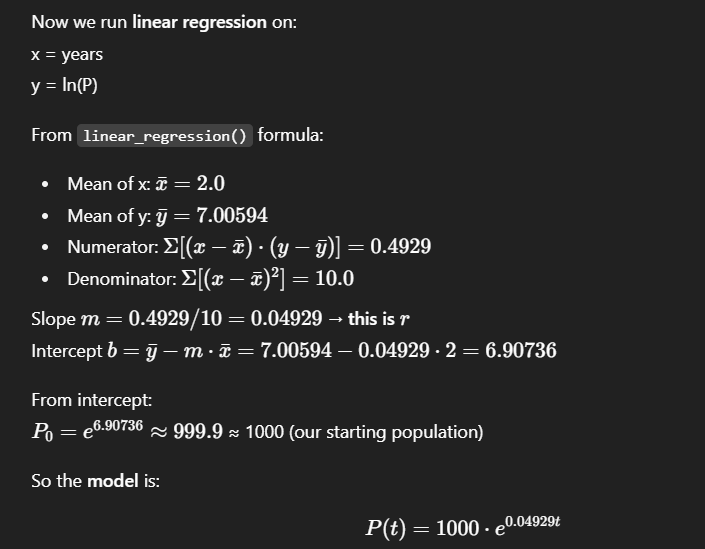

In [ ]:
# --------------------------
# 4. LOGISTIC FIT (SCAN K)
# --------------------------


5. Logistic Growth Model (Carrying Capacity)
In reality, population cannot grow forever — resources limit growth.
The logistic model accounts for this:

𝑑
𝑃
𝑑
𝑡
=
𝑟
𝑃
(
1
−
𝑃
𝐾
)
dt
dP
​
 =rP(1−
K
P
​
 )
Where:

𝐾
K = carrying capacity (max sustainable population)

When
𝑃
P is small, growth ≈ exponential

As
𝑃
P approaches
𝐾
K, growth slows

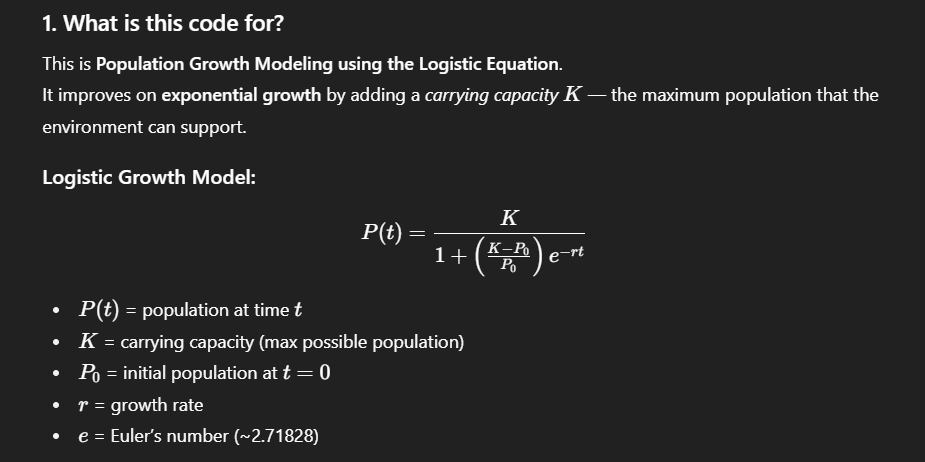

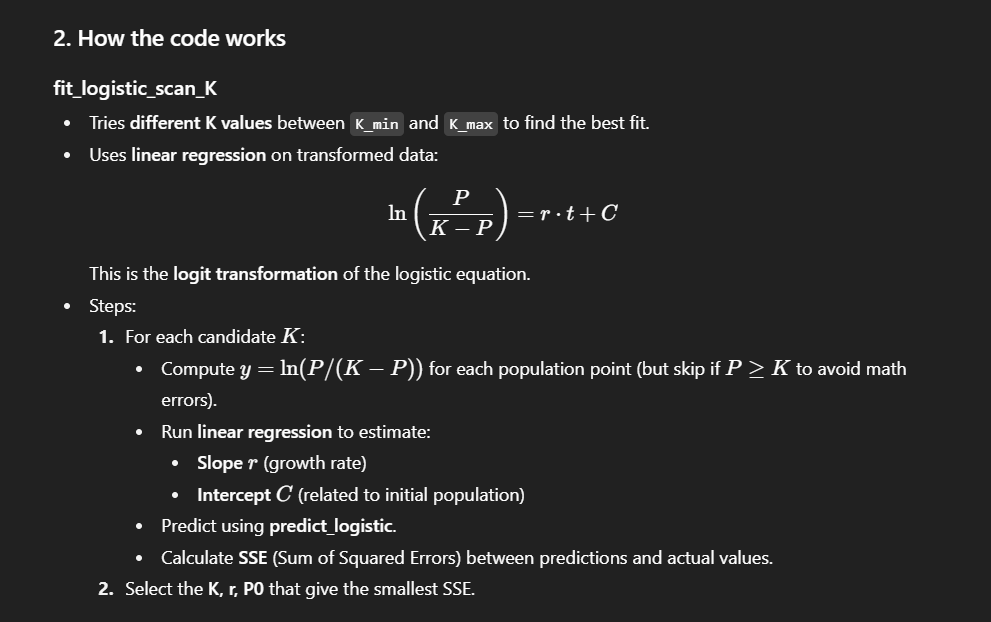

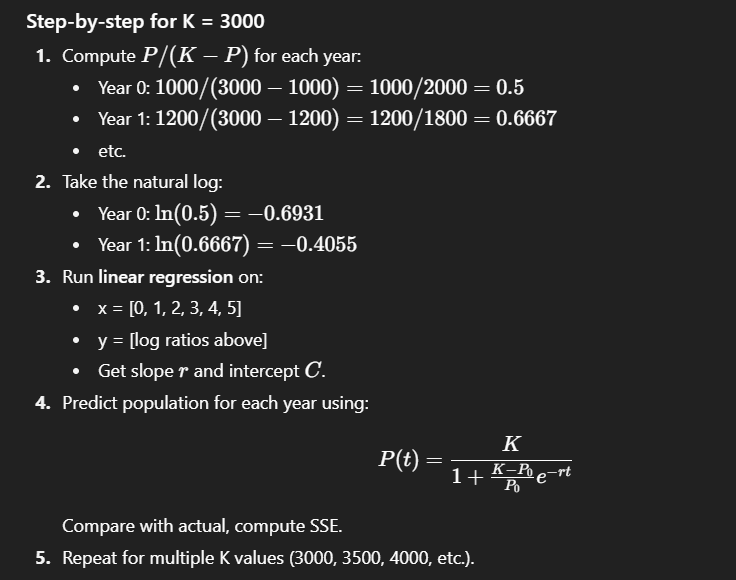

In [24]:
# Logistic prediction
def predict_logistic(P0, r, K, years):
    return [K / (1 + ((K - P0) / P0) * math.exp(-r * t)) for t in years]

# SSE calculation
def sse(actual, predicted):
    return sum((a - p)**2 for a, p in zip(actual, predicted))

In [30]:
# Logistic fit with scanning for best K
def fit_logistic_scan_K(years, popu, K_min, K_max, K_step):
    best_sse = float("inf")
    best_params = None
    for K in [K_min + i*K_step for i in range(int((K_max-K_min)/K_step)+1)]:
        try:
            ys = [math.log(P / (K - P)) for P in popu if P < K]
            valid_years = [years[i] for i in range(len(popu)) if popu[i] < K]
            if len(ys) != len(valid_years):
                continue
            r_hat, C_hat = linear_regression(valid_years, ys)
            P0_hat = popu[0]
            preds = predict_logistic(P0_hat, r_hat, K, years)
            sse_val = sse(popu, preds)
            print(f"K={K}, r={r_hat:.4f}, SSE={sse_val:.2f}")
            if sse_val < best_sse:
                best_sse = sse_val
                best_params = (K, r_hat, P0_hat, best_sse)
        except ValueError:
            continue
    return best_params

In [31]:
best_K, best_r, best_P0, best_error = fit_logistic_scan_K(years, popu, K_min=2800, K_max=4000, K_step=100)

print("\nBest Fit Parameters:")
print(f"K (carrying capacity) = {best_K}")
print(f"r (growth rate) = {best_r:.4f}")
print(f"P0 (initial pop) = {best_P0}")


K=2800, r=0.1281, SSE=17185059.75
K=2900, r=0.1216, SSE=15036640.58
K=3000, r=0.1087, SSE=12518454.98
K=3100, r=0.1006, SSE=10618960.82
K=3200, r=0.0948, SSE=9086854.95
K=3300, r=0.1017, SSE=9363043.95
K=3400, r=0.0960, SSE=8158534.79
K=3500, r=0.0912, SSE=7153909.82
K=3600, r=0.0875, SSE=6425368.27
K=3700, r=0.0846, SSE=5909690.82
K=3800, r=0.0822, SSE=5576328.82
K=3900, r=0.0803, SSE=5411353.53
K=4000, r=0.0786, SSE=5410584.76

Best Fit Parameters:
K (carrying capacity) = 4000
r (growth rate) = 0.0786
P0 (initial pop) = 1000


In [32]:
print(f"Error (SSE) = {best_error:.2f}")

Error (SSE) = 5410584.76


In [34]:


# Predictions with best parameters
predicted = predict_logistic(best_P0, best_r, best_K, years)
print("\nYear | Actual | Predicted")
for y, a, p in zip(years, popu, predicted):
    print(f"{y:>4} | {a:>6} | {p:>9.2f}")


Year | Actual | Predicted
   0 |   1000 |   1000.00
   1 |   1050 |   1060.13
   2 |   1103 |   1122.53
   3 |   1158 |   1187.12
   4 |   1216 |   1253.80
   5 |   1277 |   1322.47
   6 |   1341 |   1392.99
   7 |   1408 |   1465.22
   8 |   1478 |   1538.98
   9 |   1552 |   1614.09
  10 |   1500 |   1690.34
  11 |   1485 |   1767.53
  12 |   1530 |   1845.43
  13 |   1582 |   1923.80
  14 |   1636 |   2002.41
  15 |   1693 |   2081.01
  16 |   1753 |   2159.36
  17 |   1816 |   2237.22
  18 |   1881 |   2314.36
  19 |   1948 |   2390.55
  20 |   2018 |   2465.58
  21 |   2090 |   2539.25
  22 |   2165 |   2611.37
  23 |   2242 |   2681.79
  24 |   2322 |   2750.34
  25 |   2405 |   2816.90
  26 |   2491 |   2881.35
  27 |   2580 |   2943.61
  28 |   2672 |   3003.61
  29 |   2767 |   3061.28
  30 |   2700 |   3116.60
  31 |   2685 |   3169.54
  32 |   2740 |   3220.10
  33 |   2810 |   3268.30
  34 |   2882 |   3314.15
  35 |   2957 |   3357.69
  36 |   3035 |   3398.97
  37 |   31